> **Completed run.** This copy of the notebook was run end to end on 30 September 2026 with its default settings and data from the Hugging Face Hub, so you can read every output without running it (every cell ran; 22 minutes). It was run on an Apple M1 Pro rather than a Colab T4: the installs were skipped and QLoRA ran as LoRA in bfloat16, because 4-bit quantisation needs an NVIDIA GPU. Your results on Colab will differ slightly.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/healthcare-sms-urgency/notebook.ipynb)
[![View on GitHub](https://img.shields.io/badge/View%20on-GitHub-black?logo=github)](https://github.com/aims-ai-research-foundations/airf-capstone-project-recipes/blob/main/projects/healthcare-sms-urgency/notebook.ipynb)
[![Dataset](https://img.shields.io/badge/Dataset-Hugging%20Face-yellow?logo=huggingface)](https://huggingface.co/datasets/Similoluwa/capstone-datasets/viewer/healthcare_sms_urgency)

# Classify Healthcare SMS by Urgency

**Project Category:** Classification

## Problem

Health hotlines and SMS services receive many messages, and urgent ones can wait too long before a person reads them.

## What You'll Build

A language model (Gemma 1B) that classifies health messages as emergency, urgent or routine so human responders review the most urgent first, compared with triage nurses.

## Research Question

> When the costliest error is missing an emergency, does fine-tuning a small language model bring it closer to triage nurses than zero-shot prompting?

## What You'll Learn

- Perform zero-shot urgency classification with a language model
- Fine-tune Gemma with QLoRA on labelled triage messages
- Evaluate a safety-critical classifier by the recall of its most important class
- Compare a model with a human (triage nurse) reference
- Frame a model as a triage aid for human review and state its limits

## Setup

- Create a free Hugging Face account at [huggingface.co/join](https://huggingface.co/join).
- Accept the Gemma licence on the [Gemma 3 1B](https://huggingface.co/google/gemma-3-1b-it) and [Gemma 3 4B](https://huggingface.co/google/gemma-3-4b-it) model pages.
- Create a Hugging Face access token ([settings/tokens](https://huggingface.co/settings/tokens), **Read** access) and add it to Google Colab Secrets as `HF_TOKEN`, with notebook access turned on.
- Open the notebook in Google Colab.
- Enable a GPU under **Runtime → Change runtime type → T4 GPU**.

---

> **Important:** this is a teaching project. The classifier is a triage aid that orders messages for **human review**; it must never make clinical decisions on its own.

## Install Required Libraries

In [ ]:
!pip install -q --progress-bar off transformers==5.17.0 datasets==5.0.1 accelerate==1.15.0 peft==0.21.0 trl==1.14.0 bitsandbytes scikit-learn

## Import Libraries

In [2]:
import gc
import re

import matplotlib.pyplot as plt
import pandas as pd
import torch
import transformers
from datasets import Dataset, load_dataset
from huggingface_hub import login
from peft import LoraConfig
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, Pipeline, pipeline
from trl import SFTConfig, SFTTrainer

site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Log in to Hugging Face so the gated Gemma models can be downloaded.
try:
    from google.colab import userdata

    login(token=userdata.get("HF_TOKEN"))
except ImportError:
    pass  # Outside Colab, run `hf auth login` once in a terminal instead.

## Settings

In [4]:
MODEL_ID = "google/gemma-3-1b-it"
BATCH_SIZE = 16
SEED = 42

## Helpers

Reusable functions used in the experiment below. Read them to see how each step works.

In [5]:
transformers.logging.set_verbosity_error()  # Hide repeated generation-config warnings.


def load_chat_model(model_id: str) -> Pipeline:
    """Loads a Gemma chat model as a text-generation pipeline."""
    pipe = pipeline("text-generation", model=model_id, dtype=torch.bfloat16, device_map="auto")
    pipe.tokenizer.padding_side = "left"  # Decoder-only models must be left-padded for batching.
    return pipe


def generate(
    pipe: Pipeline,
    prompts: list[str],
    max_new_tokens: int,
    batch_size: int = 8,
    temperature: float = 0.0,
) -> list[str]:
    """Generates one chat reply per prompt in batches (greedy unless a temperature is given)."""
    sampling = (
        {"do_sample": True, "temperature": temperature} if temperature > 0 else {"do_sample": False}
    )
    replies = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        chats = [[{"role": "user", "content": p}] for p in prompts[i : i + batch_size]]
        outputs = pipe(chats, max_new_tokens=max_new_tokens, batch_size=batch_size, **sampling)
        replies += [o[0]["generated_text"][-1]["content"].strip() for o in outputs]
    return replies


def parse_label(reply: str, labels: list[str]) -> str:
    """Maps a model reply to a valid label, or 'invalid' if none is found."""
    text = re.sub(r"[^a-z0-9_]+", "_", reply.lower()).strip("_")
    if text in labels:
        return text
    found = [label for label in labels if label in text]
    return max(found, key=len) if found else "invalid"


def classification_metrics(
    y_true: list[str], y_pred: list[str], labels: list[str]
) -> dict[str, float]:
    """Computes accuracy, macro-F1 and the share of invalid predictions."""
    present = [
        label for label in labels if label in set(y_true)
    ]  # 'invalid' and absent classes do not count
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, labels=present, average="macro", zero_division=0),
        "Invalid outputs": sum(p == "invalid" for p in y_pred) / len(y_pred),
    }


def urgency_metrics(y_true: list[str], y_pred: list[str], labels: list[str]) -> dict[str, float]:
    """Adds emergency-class recall and precision to the standard classification metrics."""
    metrics = classification_metrics(y_true, y_pred, labels)
    metrics["Emergency recall"] = recall_score(
        y_true, y_pred, labels=["emergency"], average="macro", zero_division=0
    )
    metrics["Emergency precision"] = precision_score(
        y_true, y_pred, labels=["emergency"], average="macro", zero_division=0
    )
    return metrics

## Load Dataset

Emergency-department triage records rewritten as short patient (or relative) text messages. Labels come from three triage experts: **emergency** (KTAS 1–2), **urgent** (KTAS 3) and **routine** (KTAS 4–5). `ktas_nurse` is the triage nurse's original decision, which we use as a human reference.

In [6]:
dataset = load_dataset(
    "Similoluwa/capstone-datasets",
    "healthcare_sms_urgency",
    revision="v5.0",
)

dataset

Generating train split:   0%|          | 0/879 [00:00<?, ? examples/s]

Generating train split: 100%|██████████| 879/879 [00:00<00:00, 95428.72 examples/s]

Generating validation split:   0%|          | 0/188 [00:00<?, ? examples/s]

Generating validation split: 100%|██████████| 188/188 [00:00<00:00, 46169.52 examples/s]

Generating test split:   0%|          | 0/189 [00:00<?, ? examples/s]

Generating test split: 100%|██████████| 189/189 [00:00<00:00, 62680.75 examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'age', 'sex', 'chief_complaint_raw', 'ktas_expert', 'ktas_nurse', 'source'],
        num_rows: 879
    })
    validation: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'age', 'sex', 'chief_complaint_raw', 'ktas_expert', 'ktas_nurse', 'source'],
        num_rows: 188
    })
    test: Dataset({
        features: ['id', 'text', 'label', 'label_text', 'language', 'age', 'sex', 'chief_complaint_raw', 'ktas_expert', 'ktas_nurse', 'source'],
        num_rows: 189
    })
})

In [7]:
LABELS = dataset["train"].features["label"].names
train = dataset["train"].to_pandas()
validation = dataset["validation"].to_pandas()
test = dataset["test"].to_pandas()

pd.DataFrame(
    {"train": train["label_text"].value_counts(), "test": test["label_text"].value_counts()}
)

,train,test
label_text,,
routine,372,80
urgent,337,73
emergency,170,36


In [8]:
train.groupby("label_text").sample(2, random_state=SEED)[["text", "label_text"]]

,text,label_text
761,Need advice. I have chest pain. Pain is 3/10. ...,emergency
162,Need advice. I have chest pain. Pain is 3/10. ...,emergency
183,Need advice. I have pain in both shoulders. Pa...,routine
213,77M here. I have left hip pain after an injury...,routine
406,61M here. I have an open wound after an injury...,urgent
834,Need advice. I have a skin rash. Pain is 5/10....,urgent


## Build and Run the Model

```text
Triage nurse   the nurse's original decision (human reference)
Zero-shot      label definitions + message → Gemma → label
QLoRA          Gemma fine-tuned on 879 labelled messages → label
```

In [9]:
KTAS_TO_LABEL = {1: "emergency", 2: "emergency", 3: "urgent", 4: "routine", 5: "routine"}
test["nurse"] = test["ktas_nurse"].map(KTAS_TO_LABEL)

### Zero-shot Gemma

In [10]:
PROMPT = """You help a health hotline decide which text messages a nurse should read first.

Classify the urgency of this message:
- emergency: may be life-threatening and needs help immediately
- urgent: needs medical attention soon, but is not immediately life-threatening
- routine: can safely wait for a normal appointment

Message: {text}

Answer with exactly one word: emergency, urgent or routine."""

pipe = load_chat_model(MODEL_ID)
replies = generate(
    pipe, [PROMPT.format(text=t) for t in test["text"]], max_new_tokens=8, batch_size=BATCH_SIZE
)
test["zero_shot"] = [parse_label(r, LABELS) for r in replies]

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/340 [00:00<00:46,  7.28it/s]

Loading weights:  30%|███       | 102/340 [00:00<00:00, 516.89it/s]

Loading weights:  60%|█████▉    | 203/340 [00:00<00:00, 723.67it/s]

Loading weights:  89%|████████▉ | 304/340 [00:00<00:00, 821.80it/s]

...

 75%|███████▌  | 9/12 [00:17<00:05,  1.86s/it]

 83%|████████▎ | 10/12 [00:18<00:03,  1.87s/it]

 92%|█████████▏| 11/12 [00:20<00:01,  1.87s/it]

100%|██████████| 12/12 [00:22<00:00,  1.78s/it]

100%|██████████| 12/12 [00:22<00:00,  1.86s/it]

In [11]:
# Free GPU memory before loading the next model.
del pipe
gc.collect()
torch.cuda.empty_cache()

### QLoRA fine-tuning

The same prompt is used, so the only difference is what the model learns from the labelled messages.

In [12]:
def to_chat(df: pd.DataFrame) -> Dataset:
    """Converts messages and urgency labels into prompt-completion chat examples."""
    return Dataset.from_list(
        [
            {
                "prompt": [{"role": "user", "content": PROMPT.format(text=t)}],
                "completion": [{"role": "assistant", "content": label}],
            }
            for t, label in zip(df["text"], df["label_text"])
        ]
    )


# 4-bit quantisation needs a CUDA GPU; T4s lack native bfloat16, so compute runs in float32 there.
compute_dtype = (
    torch.bfloat16 if torch.cuda.is_bf16_supported(including_emulation=False) else torch.float32
)
quantization = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=compute_dtype
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=quantization, dtype=compute_dtype, device_map="auto"
)

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir="gemma-sms-urgency-qlora",
        num_train_epochs=3,
        per_device_train_batch_size=16,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        warmup_steps=0.05,  # a float below 1 is a fraction of all training steps
        max_length=256,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        seed=SEED,
    ),
    train_dataset=to_chat(train),
    eval_dataset=to_chat(validation),
    processing_class=tokenizer,
    peft_config=LoraConfig(
        r=16, lora_alpha=32, lora_dropout=0.05, target_modules="all-linear", task_type="CAUSAL_LM"
    ),
)
trainer.train()

Loading weights:   0%|          | 0/340 [00:00<?, ?it/s]

Loading weights:   1%|▏         | 5/340 [00:00<00:06, 49.85it/s]

Loading weights:  36%|███▌      | 121/340 [00:00<00:00, 693.08it/s]

Loading weights:  70%|██████▉   | 237/340 [00:00<00:00, 901.72it/s]

Loading weights: 100%|██████████| 340/340 [00:00<00:00, 862.91it/s]

...

{'loss': '0.1593', 'grad_norm': '1.055', 'learning_rate': '1.34e-05', 'entropy': '0.1729', 'num_tokens': '2.618e+05', 'mean_token_accuracy': '0.9375', 'epoch': '2.545'}


{'loss': '0.2016', 'grad_norm': '1.172', 'learning_rate': '5.146e-06', 'entropy': '0.1843', 'num_tokens': '2.804e+05', 'mean_token_accuracy': '0.9271', 'epoch': '2.727'}


{'loss': '0.2095', 'grad_norm': '1.277', 'learning_rate': '7.291e-07', 'entropy': '0.1747', 'num_tokens': '2.993e+05', 'mean_token_accuracy': '0.9146', 'epoch': '2.909'}


{'eval_loss': '0.2009', 'eval_runtime': '23.82', 'eval_samples_per_second': '7.893', 'eval_steps_per_second': '1.008', 'eval_entropy': '0.1862', 'eval_num_tokens': '3.084e+05', 'eval_mean_token_accuracy': '0.9236', 'epoch': '3'}
{'train_runtime': '1217', 'train_samples_per_second': '2.167', 'train_steps_per_second': '0.136', 'train_loss': '0.3233', 'epoch': '3'}


TrainOutput(global_step=165, training_loss=0.32326673738884204, metrics={'train_runtime': 1216.7974, 'train_samples_per_second': 2.167, 'train_steps_per_second': 0.136, 'train_loss': 0.32326673738884204, 'epoch': 3.0})

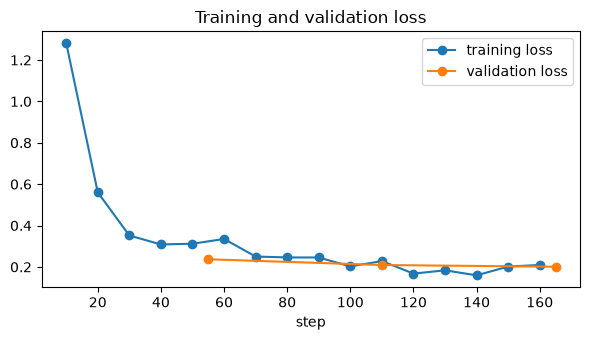

In [13]:
log = pd.DataFrame(trainer.state.log_history)
ax = log.dropna(subset=["loss"]).plot(
    x="step", y="loss", marker="o", label="training loss", figsize=(6, 3.5)
)
log.dropna(subset=["eval_loss"]).plot(
    x="step",
    y="eval_loss",
    marker="o",
    label="validation loss",
    ax=ax,
    title="Training and validation loss",
)
plt.tight_layout()

In [14]:
# Training switches the key-value cache off; turn it back on, or generation becomes very slow.
trainer.model.config.use_cache = True
trainer.model.eval()  # Switch off dropout for deterministic generation.
tokenizer.padding_side = "left"
fine_tuned = pipeline("text-generation", model=trainer.model, tokenizer=tokenizer)
replies = generate(
    fine_tuned,
    [PROMPT.format(text=t) for t in test["text"]],
    max_new_tokens=8,
    batch_size=BATCH_SIZE,
)
test["qlora"] = [parse_label(r, LABELS) for r in replies]

  0%|          | 0/12 [00:00<?, ?it/s]

  8%|▊         | 1/12 [00:02<00:22,  2.04s/it]

 17%|█▋        | 2/12 [00:04<00:20,  2.05s/it]

 25%|██▌       | 3/12 [00:06<00:18,  2.04s/it]

 33%|███▎      | 4/12 [00:08<00:16,  2.04s/it]

...

 75%|███████▌  | 9/12 [00:18<00:06,  2.03s/it]

 83%|████████▎ | 10/12 [00:20<00:04,  2.03s/it]

 92%|█████████▏| 11/12 [00:22<00:02,  2.03s/it]

100%|██████████| 12/12 [00:24<00:00,  2.08s/it]

100%|██████████| 12/12 [00:24<00:00,  2.05s/it]

## Evaluate

Emergency recall is the headline metric: a missed emergency is the most costly error.

In [15]:
approaches = {
    "Triage nurse (human reference)": "nurse",
    "Gemma, zero-shot": "zero_shot",
    "Gemma, QLoRA fine-tuned": "qlora",
}
results = pd.DataFrame(
    {
        name: urgency_metrics(test["label_text"].tolist(), test[col].tolist(), LABELS)
        for name, col in approaches.items()
    }
).T
results.round(3)

,Accuracy,Macro-F1,Invalid outputs,Emergency recall,Emergency precision
Triage nurse (human reference),0.910,0.903,0.0,0.833,0.938
"Gemma, zero-shot",0.381,0.353,0.0,0.528,0.388
"Gemma, QLoRA fine-tuned",0.804,0.779,0.0,0.639,0.719


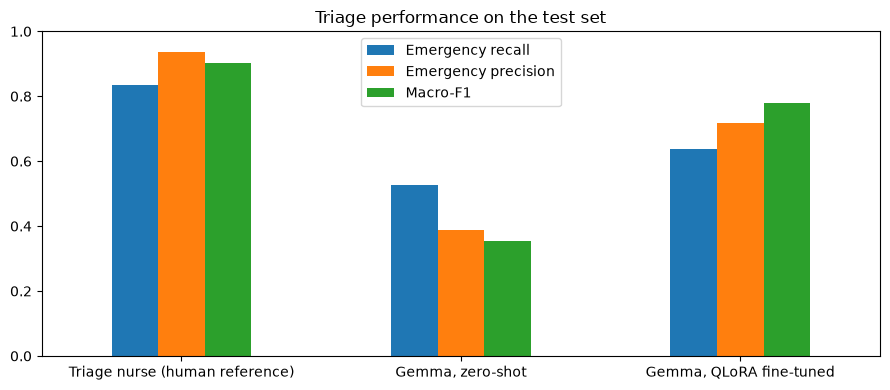

In [16]:
results[["Emergency recall", "Emergency precision", "Macro-F1"]].plot.bar(
    rot=0, ylim=(0, 1), figsize=(9, 4), title="Triage performance on the test set"
)
plt.tight_layout()

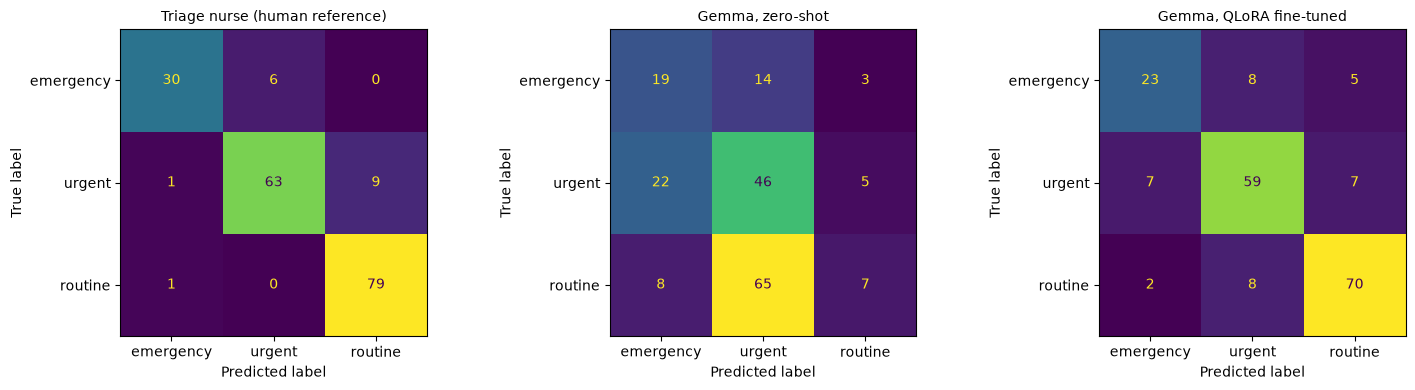

In [17]:
fig, axes = plt.subplots(1, len(approaches), figsize=(5 * len(approaches), 4))
for ax, (name, col) in zip(axes, approaches.items()):
    ConfusionMatrixDisplay.from_predictions(
        test["label_text"], test[col], labels=LABELS, ax=ax, colorbar=False
    )
    ax.set_title(name, fontsize=10)
plt.tight_layout()

In [18]:
# Emergencies the fine-tuned model marked routine (under-triage) are the most dangerous errors.
test[(test["label_text"] == "emergency") & (test["qlora"] != "emergency")][
    ["text", "chief_complaint_raw", "nurse", "qlora"]
]

,text,chief_complaint_raw,nurse,qlora
22,"Hi, I'm an 80 year old man. I have difficulty ...",dyspnea,emergency,urgent
35,"Hi, I'm a 70 year old woman. I have chest disc...","discomfort, chest",emergency,urgent
57,39F here. I have vaginal bleeding. Please advise.,Vaginal Bleeding,emergency,urgent
68,"Hello, I am 48 (male) and I have difficulty br...",dyspnea,emergency,urgent
74,"Hi, I'm a 61 year old woman. I have a fever. W...",fever,urgent,routine
81,"Hi, my mother is 76 and has a headache. She on...",headache,emergency,routine
96,Need advice. I have difficulty breathing. I'm ...,dyspnea,emergency,urgent
106,82F here. I have cold legs. Please advise.,다리 차가움,emergency,routine
118,Need advice. I have chest discomfort. Pain is ...,With chest discomfort,emergency,urgent
150,Need advice. I have a chemical burn after an i...,Chemical Burn,emergency,routine


## Reflect

Use the evidence above (the results tables, charts and examples) to answer:

- How many emergencies did each approach miss? Is accuracy a good summary of safety here?
- Read the missed emergencies. What information would a nurse use that the message does not contain?
- How would you make the model more cautious, and what would that cost in false alarms?
- What must a human always check before a model like this is used on a real hotline?

## What Next?

Ways to build on this project:

- Make the model more cautious, for example by weighting emergency examples in training or asking it to choose emergency when unsure
- Compare with Gemma 4B, zero-shot and few-shot
- Translate messages into a local language with native-speaker review and re-evaluate
- Build a triage queue that sorts incoming messages for a nurse, most urgent first, and measure how long emergencies wait